In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

df = pd.read_csv("data\pa_transactor_annotated_clean.csv")
df.head()

,index,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,0,3008,b60b4b0c-5067-4c44-826b-aac5a22d2609,franklin county reagan coalition,PA,Committee,NaN,7172670032
1,1,3009,c7461f6f-6118-48eb-a499-fc97d108f66f,nextgen climate action committee,PA,Committee,NaN,NaN
2,2,3010,14ae9bb5-57dc-422b-b517-8eaaf011cec8,zarwin baum good government pac,PA,Committee,NaN,2155692800
3,3,3011,7ab4636b-3513-4143-9c17-94115c991a75,mid-atlantic laborers' political league,PA,Committee,NaN,7038604194
4,4,3012,a445eb91-c855-410d-a046-0a942159d496,toll bros inc pac,PA,Committee,NaN,2159388000


In [51]:
# clean string columns
for col in ['transactor_type', 'reported_state', 'party', 'full_name']:
    df[col] = df[col].astype(str).str.strip().str.title()
    print(df[col])

# replace filler or unknown values with NA
filler_values = ['Na', 'N/A', 'None', 'Unknown', 'Nan']
df.replace(filler_values, pd.NA, inplace=True)

# drop rows with missing key fields
df.dropna(subset=['full_name', 'transactor_type', 'reported_state', 'party'], inplace=True)

# drop duplicate donors based on id or name
df = df.drop_duplicates(subset=['id', 'full_name'])

# encode transactor_type as numeric labels
df['label'] = df['transactor_type'].factorize()[0]

# features and target for under-sampling
X = df[['transactor_type']]
y = df['label']

# apply random under-sampling to balance the classes
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# merge resampled data with full original data
df_resampled = pd.merge(pd.concat([X_resampled, y_resampled.rename("label")], axis = 1),
                        df[['id', 'full_name', 'transactor_type', 'reported_state', 'party', 'label']],
                        on = ['transactor_type', 'label'], how = 'left'
                        ).drop_duplicates().reset_index(drop = True)

# print class distribution and sample data
print("Balanced transactor_type counts:")
print(df_resampled['transactor_type'].value_counts())

print("Sample of cleaned and balanced data:")
print(df_resampled[['full_name', 'transactor_type', 'reported_state', 'party']].head())

0        Committee
1        Committee
2        Committee
3        Committee
4        Committee
           ...    
10120    Candidate
10121    Candidate
10122    Candidate
10123    Candidate
10124    Committee
Name: transactor_type, Length: 10125, dtype: object
0        Pa
1        Pa
2        Pa
3        Pa
4        Pa
         ..
10120    Pa
10121    Pa
10122    Pa
10123    Pa
10124    Pa
Name: reported_state, Length: 10125, dtype: object
0                     Nan
1                     Nan
2                     Nan
3                     Nan
4                     Nan
               ...       
10120    Democratic Party
10121    Democratic Party
10122    Democratic Party
10123    Democratic Party
10124    Democratic Party
Name: party, Length: 10125, dtype: object
0               Franklin County Reagan Coalition
1               Nextgen Climate Action Committee
2                Zarwin Baum Good Government Pac
3        Mid-Atlantic Laborers' Political League
4                              T

NameError: name 'RandomUnderSampler' is not defined

In [64]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['full_name'])

In [65]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Committee':
        return 1
    else:
        return 0
y = np.vectorize(convert_bool)(df['transactor_type'])

(array([ 468.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2064.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

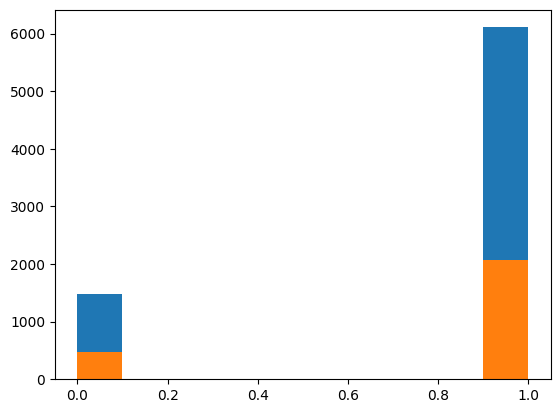

In [66]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.25, random_state = 42)
plt.hist(y_train)
plt.hist(y_val)

In [67]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
predicted_y = rfc.predict(X_val)

In [68]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

Accuracy: 95.22116903633491
Recall: 98.44961240310077
Precision: 95.8038661008958
f1_score: 97.10872162485066


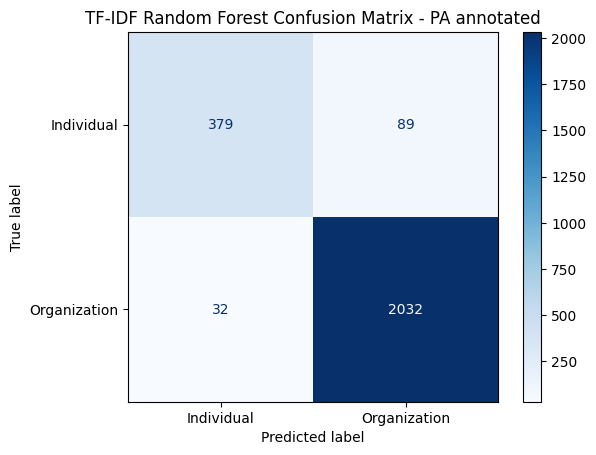

In [69]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TF-IDF Random Forest Confusion Matrix - PA annotated")
#plt.savefig('TF-IDF Random Forest Confusion Matrix - PA annotated.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [70]:
inverse_names_clean

['marsh laban',
 'ellen ceisler',
 'follweiler archie',
 'theresa brunson',
 'ida chen',
 'ellen ceisler',
 'schroeder meghan',
 'hyams carrie',
 'morgan cephas',
 'pradhan rajeev',
 'vedder clyde',
 'neil slenker',
 'alan benyak',
 'tina burgess',
 'hershey brandi',
 'jason rubin',
 'maggie borski',
 'fisher mariah',
 'gerard geiger',
 'moton ruth',
 'pisciottano nickolas',
 'gray janon',
 'tsai stella',
 'clark mitchell',
 'vedder clyde',
 'tallman will',
 'klein arnie',
 'mary webber',
 'jordan yeager',
 'county of smith court common pleas york suzanne',
 'emily kinkead',
 'morris royce',
 'clifford glovier',
 'com judge to elect thompson sandra',
 'bob rudy',
 'diamond russell',
 'gerard kosinski',
 'pashinski edwin',
 'stone sobieralski',
 'henry shook ashley',
 'aaron robert kelley',
 'esq reilly andrew',
 'raymond zaborney',
 'jonelle eshbach',
 'jose winston dilone martinez',
 'joe murzyn',
 'grove seth',
 'jake wheatley',
 'nicholas mcgaw',
 'buggey stanley',
 'chad vilushis',

In [71]:
misclassified = np.where(y_val != predicted_y)[0]

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_val[i]}, Predicted: {predicted_y[i]}")
	print("---")

Number of misclassified samples: 121
ctr: 0
Index: 55
Full Name: izzard jamar
True Label: 0, Predicted: 1
---
ctr: 1
Index: 61
Full Name: grimm charity krups
True Label: 0, Predicted: 1
---
ctr: 2
Index: 100
Full Name: weston timothy
True Label: 1, Predicted: 0
---
ctr: 3
Index: 141
Full Name: danielle friel otten
True Label: 0, Predicted: 1
---
ctr: 4
Index: 159
Full Name: terrance shepler
True Label: 0, Predicted: 1
---
ctr: 5
Index: 181
Full Name: michael 2016 bagdes canning
True Label: 1, Predicted: 0
---
ctr: 6
Index: 211
Full Name: ward kim
True Label: 0, Predicted: 1
---
ctr: 7
Index: 277
Full Name: danielle friel otten
True Label: 0, Predicted: 1
---
ctr: 8
Index: 305
Full Name: judge julia munley
True Label: 0, Predicted: 1
---
ctr: 9
Index: 317
Full Name: jr alex minishak
True Label: 1, Predicted: 0
---
ctr: 10
Index: 333
Full Name: for pa anderson house marc
True Label: 0, Predicted: 1
---
ctr: 11
Index: 345
Full Name: duane milne
True Label: 0, Predicted: 1
---
ctr: 12
Inde